# Stacy Cherenge
## House Prices — Encoding Techniques

Encoding applied to the House Prices dataset:
- **Ordinal encoding** for the ranked quality/condition columns
- **One-hot encoding** for the unordered (nominal) categorical columns
- **Cyclic (sine/cosine) encoding** for `MoSold`

## Importing the necessary Libraries 
In the cell below weimport the necessary libraries and getting to understand the dataset; for both the test and the train csv, seeing the missing values and datas and what we will need to do based on the data

In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score


## 2. Loading the data

`train.csv` has the answer column (`SalePrice`), that's what we train and validate on. `test.csv` has no `SalePrice`, it only gets a final prediction once, at the very end, and isn't used during training.

In [25]:
df_hseptrain = pd.read_csv('train.csv')
df_hseptest = pd.read_csv('test.csv')

print('train data set has got {} rows and {} columns'.format(df_hseptrain.shape[0], df_hseptrain.shape[1]))
print('test data set has got {} rows and {} columns'.format(df_hseptest.shape[0], df_hseptest.shape[1]))

df_hseptrain.head()

train data set has got 1460 rows and 81 columns
test data set has got 1459 rows and 80 columns


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


## 3. Fixing `MSSubClass`'s data type

`MSSubClass` is stored as a number (20, 60, 90...) but the values are actually **codes for a dwelling type**.Converting it to a string turns it into what it actually is: a category, so it gets one-hot encoded later along with the other nominal columns.

In [26]:
df_hseptrain['MSSubClass'] = df_hseptrain['MSSubClass'].astype(str)
df_hseptest['MSSubClass'] = df_hseptest['MSSubClass'].astype(str)

## 4. Separating features (X) from the target (y)
`SalePrice` is the value we're trying to predict, so it comes out of `X` and becomes `y` on its own.

In [9]:
X = df_hseptrain.drop(['SalePrice'], axis=1)
y = df_hseptrain['SalePrice']

## 5. Splitting the train data

`X_val`/`y_val` stand in for "new, unseen data" while we're developing the model; `test.csv` is saved for a single final prediction pass at the end.

In [27]:
X_train, X_val, y_train, y_val = train_test_split(X, y, random_state=42, test_size=0.2)

print(f"Original X shape: {X.shape} | Original y shape: {y.shape}")
print(f"Train X shape:   {X_train.shape} | Train y shape:   {y_train.shape}")
print(f"Val X shape:     {X_val.shape} | Val y shape:     {y_val.shape}")

Original X shape: (1460, 80) | Original y shape: (1460,)
Train X shape:   (1168, 80) | Train y shape:   (1168,)
Val X shape:     (292, 80) | Val y shape:     (292,)


## 6. Finding missing values

In [28]:
missing_values = X.isnull().sum()
missing_values = missing_values[missing_values > 0].sort_values(ascending=False)
missing_values

PoolQC          1453
MiscFeature     1406
Alley           1369
Fence           1179
MasVnrType       872
FireplaceQu      690
LotFrontage      259
GarageType        81
GarageYrBlt       81
GarageFinish      81
GarageQual        81
GarageCond        81
BsmtExposure      38
BsmtFinType2      38
BsmtQual          37
BsmtCond          37
BsmtFinType1      37
MasVnrArea         8
Electrical         1
dtype: int64

## 7. Correcting missing values
Two different situations show up in regards to the `data_description.txt`, and they need two different fixes:

**A. `NA` is a real category, not missing data.** For columns like `PoolQC`, `GarageType`, `BsmtQual`, or `Fence`, `NA` specifically means *"this house doesn't have this feature"* ;no pool, no garage, no basement, no fence. The fix is to fill these with an explicit `"None"` category (or `0` for the numeric equivalents `GarageYrBlt`/`MasVnrArea`).

**B. The value is genuinely missing.** `Electrical` (1 row) and `LotFrontage` (259 rows) have no such documented meaning for their gaps — these are real missing data points, filled with the most common value (mode) / typical value (median).

**Important:** the mode and median are calculated from `X_train` only, then reused on `X_val` and the test set. If they were calculated from the full dataset, information from the validation/test rows would leak into how the training data gets filled;the same leakage risk as evaluating a model on data it's already seen in another form.


In [29]:
none_means_no_feature = [
    'PoolQC', 'MiscFeature', 'Alley', 'Fence', 'FireplaceQu',
    'GarageType', 'GarageFinish', 'GarageQual', 'GarageCond',
    'BsmtExposure', 'BsmtFinType2', 'BsmtQual', 'BsmtCond', 'BsmtFinType1',
    'MasVnrType'
]
zero_means_no_feature = ['GarageYrBlt', 'MasVnrArea']

for df in (X_train, X_val, df_hseptest):
    df[none_means_no_feature] = df[none_means_no_feature].fillna("None")
    df[zero_means_no_feature] = df[zero_means_no_feature].fillna(0)

electrical_mode = X_train['Electrical'].mode()[0]
lotfrontage_median = X_train['LotFrontage'].median()

for df in (X_train, X_val, df_hseptest):
    df['Electrical'] = df['Electrical'].fillna(electrical_mode)
    df['LotFrontage'] = df['LotFrontage'].fillna(lotfrontage_median)

print('Remaining missing values in X_train:', X_train.isnull().sum().sum())
print('Remaining missing values in X_val:  ', X_val.isnull().sum().sum())
print('Remaining missing values in test:   ', df_hseptest.isnull().sum().sum())

Remaining missing values in X_train: 0
Remaining missing values in X_val:   0
Remaining missing values in test:    22


### 7a. Catch-all for the official test set

Kaggle's `test.csv` has a small number of missing values in columns that happen to be complete in `train.csv` (e.g. a handful of gaps in `MSZoning`, `GarageArea`, `BsmtFullBath`). Your own `X_train`/`X_val` split can never surface these, since they're both drawn from `train.csv`;  so without this step, the pipeline would work perfectly right up until the final test predictions and then fail. The fallback fills any column still missing values with a statistic learned from `X_train` only: median for numeric columns, mode for categorical ones.

In [30]:
numeric_cols_remaining = df_hseptest.select_dtypes(include=[np.number]).columns
categorical_cols_remaining = df_hseptest.select_dtypes(exclude=[np.number]).columns

for col in numeric_cols_remaining:
    if df_hseptest[col].isnull().any():
        fill_value = X_train[col].median()
        df_hseptest[col] = df_hseptest[col].fillna(fill_value)

for col in categorical_cols_remaining:
    if df_hseptest[col].isnull().any():
        fill_value = X_train[col].mode()[0]
        df_hseptest[col] = df_hseptest[col].fillna(fill_value)

print('Remaining missing values in test:', df_hseptest.isnull().sum().sum())

Remaining missing values in test: 0


## 8. Understanding the target variable
`SalePrice` is a **continuous dollar amount**, not a 0/1 label — a bar chart of value counts (as if it were a small set of categories) would be empty or meaningless, since almost every price is unique. A histogram is the right chart for a continuous variable like this.

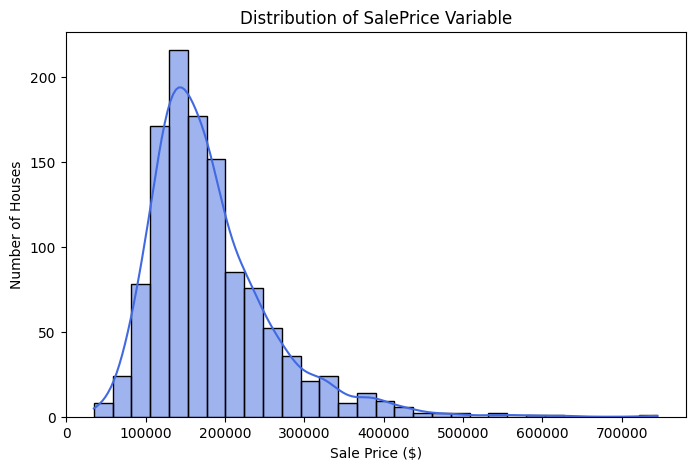

In [31]:
plt.figure(figsize=(8,5))
sns.histplot(y_train, bins=30, color='royalblue', edgecolor='black', kde=True, stat="count")
plt.xlabel('Sale Price ($)')
plt.ylabel('Number of Houses')
plt.title('Distribution of SalePrice Variable')
plt.show()

## 9. Data variables in this dataset
**Target variable**
- `SalePrice`: the property's sale price in dollars (continuous numerical)

**Ordinal categorical variables** (have a real order — ranked encoding)
- Quality & condition ratings: `ExterQual`, `ExterCond`, `BsmtQual`, `BsmtCond`, `HeatingQC`, `KitchenQual`, `FireplaceQu`, `GarageQual`, `GarageCond`, `PoolQC` (Poor → Excellent)
- Basement finish type: `BsmtFinType1`, `BsmtFinType2`
- Exposure & slope: `LandSlope`, `BsmtExposure`
- Utilities & functionality: `Utilities`, `Functional`, `GarageFinish`
- Lot regularity: `LotShape` (Irregular → Regular)

**Nominal categorical variables** (no real order — one-hot encoded)
- Location & zoning: `MSSubClass`, `MSZoning`, `Neighborhood`, `Condition1`, `Condition2`
- Building style & type: `BldgType`, `HouseStyle`, `RoofStyle`, `RoofMatl`
- Exterior features: `Exterior1st`, `Exterior2nd`, `MasVnrType`, `Foundation`
- Access & infrastructure: `Street`, `Alley`, `CentralAir`, `Electrical`, `GarageType`, `PavedDrive`, `MiscFeature`
- Lot & land: `LandContour`, `LotConfig`
- Heating type: `Heating`
- Fence: `Fence` (mixes privacy/material, no single clean order)
- Sale metadata: `SaleType`, `SaleCondition`

**Numerical variables** (left as-is, no encoding needed)
- Sizes/areas, counts, and years — already meaningful as numbers

**Cyclic feature**
- `MoSold` (month sold, 1–12) — sine/cosine transformed below

## 10. Ordinal encoding
These columns have a genuine order -`Po` < `Fa` < `TA` < `Gd` < `Ex`- so mapping them to ranked integers preserves that "better than / worse than" relationship. One-hot encoding would throw the ordering away and treat "Excellent" as no more related to "Good" than to "Poor". Where `"None"` is a valid value (no such feature), it's placed at the *bottom* of the scale, below "Poor".

In [32]:
ordinal_maps = {
    'ExterQual':    ['Po','Fa','TA','Gd','Ex'],
    'ExterCond':    ['Po','Fa','TA','Gd','Ex'],
    'BsmtQual':     ['None','Po','Fa','TA','Gd','Ex'],
    'BsmtCond':     ['None','Po','Fa','TA','Gd','Ex'],
    'HeatingQC':    ['Po','Fa','TA','Gd','Ex'],
    'KitchenQual':  ['Po','Fa','TA','Gd','Ex'],
    'FireplaceQu':  ['None','Po','Fa','TA','Gd','Ex'],
    'GarageQual':   ['None','Po','Fa','TA','Gd','Ex'],
    'GarageCond':   ['None','Po','Fa','TA','Gd','Ex'],
    'PoolQC':       ['None','Fa','TA','Gd','Ex'],
    'BsmtExposure': ['None','No','Mn','Av','Gd'],
    'BsmtFinType1': ['None','Unf','LwQ','Rec','BLQ','ALQ','GLQ'],
    'BsmtFinType2': ['None','Unf','LwQ','Rec','BLQ','ALQ','GLQ'],
    'GarageFinish': ['None','Unf','RFn','Fin'],
    'Functional':   ['Sal','Sev','Maj2','Maj1','Mod','Min2','Min1','Typ'],
    'LandSlope':    ['Gtl','Mod','Sev'],
    'Utilities':    ['ELO','NoSeWa','NoSewr','AllPub'],
    'LotShape':     ['IR3','IR2','IR1','Reg'],
}

def apply_ordinal(df, maps):
    df = df.copy()
    for col, order in maps.items():
        rank = {category: i for i, category in enumerate(order)}
        df[col] = df[col].map(rank)
    return df

X_train_enc = apply_ordinal(X_train, ordinal_maps)
X_val_enc = apply_ordinal(X_val, ordinal_maps)
test_enc = apply_ordinal(df_hseptest, ordinal_maps)

X_train_enc[list(ordinal_maps.keys())].head()


,ExterQual,ExterCond,BsmtQual,BsmtCond,HeatingQC,KitchenQual,FireplaceQu,GarageQual,GarageCond,PoolQC,BsmtExposure,BsmtFinType1,BsmtFinType2,GarageFinish,Functional,LandSlope,Utilities,LotShape
254,2,3,3,3,2,2,0,3,3,0,1,3,1,2,7,0,3,3
1066,3,2,4,3,3,2,3,3,3,0,1,1,1,2,7,0,3,2
638,2,2,2,3,3,2,0,0,0,0,1,1,1,0,7,0,3,3
799,2,2,4,3,4,3,3,3,3,0,1,5,1,1,7,0,3,3
380,2,2,3,3,2,3,4,3,3,0,1,2,1,1,7,0,3,3


## 11. One-hot encoding

Everything left in `none_means_no_feature`/other categorical columns that has **no** inherent order — a `Neighborhood` isn't "more" or "less" than another one — gets one-hot encoded instead: one binary column per category.

`OneHotEncoder` is fit on `X_train` only, then reused (`.transform`) on `X_val` and the test set. This guarantees identical output columns everywhere; `pd.get_dummies` applied separately to each dataframe can silently produce mismatched columns if a category appears in one split but not another. `handle_unknown='ignore'` means any category in `X_val`/test that never appeared in training is encoded as all-zeros instead of crashing.

In [33]:
nominal_cols = [
    'MSSubClass', 'MSZoning', 'Neighborhood', 'Condition1', 'Condition2',
    'BldgType', 'HouseStyle', 'RoofStyle', 'RoofMatl',
    'Exterior1st', 'Exterior2nd', 'MasVnrType', 'Foundation',
    'Street', 'Alley', 'CentralAir', 'Electrical', 'GarageType',
    'PavedDrive', 'MiscFeature', 'SaleType', 'SaleCondition',
    'LandContour', 'LotConfig', 'Heating', 'Fence'
]

ohe = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
ohe.fit(X_train_enc[nominal_cols])  # fit on TRAIN ONLY

def apply_ohe(df):
    encoded = ohe.transform(df[nominal_cols])
    encoded_df = pd.DataFrame(
        encoded, columns=ohe.get_feature_names_out(nominal_cols), index=df.index
    )
    return pd.concat([df.drop(columns=nominal_cols), encoded_df], axis=1)

X_train_final = apply_ohe(X_train_enc)
X_val_final = apply_ohe(X_val_enc)
test_final = apply_ohe(test_enc)

print('Feature count after one-hot encoding:', X_train_final.shape[1])

Feature count after one-hot encoding: 244


## 12. Cyclic feature encoding
Month 12 (December) and month 1 (January) are one month apart, but as plain integers, 12 and 1 look maximally far apart. Mapping the month onto a sine/cosine pair places it on a circle instead of a line, so December and January end up next to each other, the way they actually are.

In [19]:
for df in (X_train_final, X_val_final, test_final):
    df['MoSold_sin'] = np.sin(2 * np.pi * df['MoSold'] / 12)
    df['MoSold_cos'] = np.cos(2 * np.pi * df['MoSold'] / 12)
    df.drop(columns=['MoSold'], inplace=True)

X_train_final[['MoSold_sin', 'MoSold_cos']].head()

,MoSold_sin,MoSold_cos
254,1.224647e-16,-1.000000
1066,5.000000e-01,-0.866025
638,5.000000e-01,-0.866025
799,1.224647e-16,-1.000000
380,5.000000e-01,-0.866025


## 13. Training and validating a model

`SalePrice` is a continuous number, so this needs a **regression** model, not a classifier, `LogisticRegression`/`accuracy_score` (built for predicting *which category* something falls into) don't apply here. `RandomForestRegressor` predicts a continuous value directly; RMSE reports the average prediction error in dollars, and R² reports what fraction of the price variation the model explains (closer to 1 is better).

In [20]:
model = RandomForestRegressor(n_estimators=300, random_state=42)
model.fit(X_train_final, y_train)

val_preds = model.predict(X_val_final)
rf_rmse = np.sqrt(mean_squared_error(y_val, val_preds))
rf_r2 = r2_score(y_val, val_preds)

print(f"Random Forest — Validation RMSE: ${rf_rmse:,.0f}")
print(f"Random Forest — Validation R²:   {rf_r2:.3f}")

Random Forest — Validation RMSE: $28,533
Random Forest — Validation R²:   0.894


## 14. Baseline comparison

A simple `LinearRegression` as a baseline shows whether the extra complexity of the random forest is actually earning its keep, the same way the original notebook compared multiple encoding methods against each other.

In [22]:
baseline = LinearRegression()
baseline.fit(X_train_final, y_train)

baseline_preds = baseline.predict(X_val_final)
lr_rmse = np.sqrt(mean_squared_error(y_val, baseline_preds))
lr_r2 = r2_score(y_val, baseline_preds)

print(f"Linear Regression — Validation RMSE: ${lr_rmse:,.0f}")
print(f"Linear Regression — Validation R²:   {lr_r2:.3f}")

Linear Regression — Validation RMSE: $30,624
Linear Regression — Validation R²:   0.878


## 15. Summary

* Linear Regression has a Validation RMSE of  $30,624 and a Validation R² of 0.878      
* Random Forest Regressor has a Validation RMSE of $28,533 and a Validation R² of 0.894 

**What this pipeline does, end to end:** `MSSubClass` is corrected to a categorical type; missing values are split into "no such feature" (filled with `None`/`0`) versus genuinely missing (filled with a train-only mode/median); the ranked quality columns are ordinal-encoded to preserve their order; the unordered categorical columns are one-hot encoded using an encoder fit only on training data; `MoSold` is cyclically encoded; and the result is used to train and validate a regression model appropriate for a continuous target.

### Metric Breakdown

* **Random Forest Regressor** outperformed the baseline model across both metrics.
* It reduced the average prediction error (**RMSE**) by **$2,091**.
* It increased the variance explained (**R²**) by **1.6%**, capturing **89.4%** of the target's behavior.
